# Notebook 6 — Classification Supervisée

Objectif : prédire le **niveau de stress catégorisé** (Faible / Modéré / Élevé) à partir des données d'utilisation du smartphone.

**Outils :** Scikit-learn (LogisticRegression, SVC, RandomForestClassifier, DecisionTreeClassifier)

---
### Pourquoi transformer le stress en catégorie ?
Parler de "niveau de stress élevé" est plus actionnable que de prédire un score de 7.34. La catégorisation permet aussi d'évaluer l'utilité clinique du modèle (sensibilité, spécificité).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('dataset_engineered.csv')
print(f'Dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')

Dataset : 15,000 lignes × 45 colonnes


## 1. Création de la variable cible catégorielle

On discrétise `stress_level` en 3 catégories selon des seuils cliniquement pertinents :

Distribution des catégories de stress :
stress_cat
Élevé     8799
Modéré    4071
Faible    2130
Name: count, dtype: int64

Proportions :
stress_cat
Élevé     58.7%
Modéré    27.1%
Faible    14.2%
Name: proportion, dtype: object


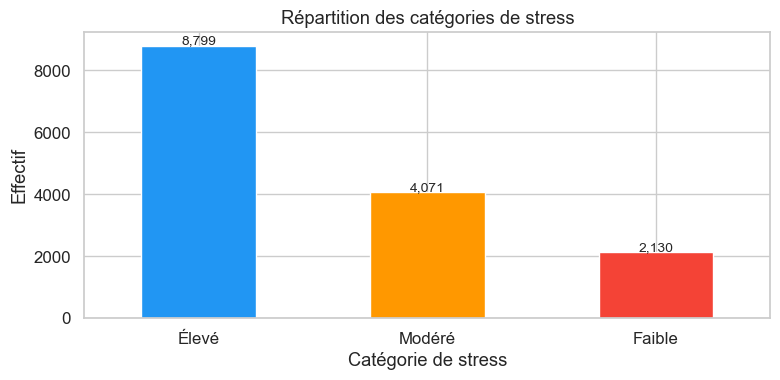

In [2]:
# Catégorisation du niveau de stress
# Seuils : 0-3.5 = Faible | 3.5-6.5 = Modéré | 6.5-10 = Élevé
df['stress_cat'] = pd.cut(
    df['stress_level'],
    bins=[0, 3.5, 6.5, 10],
    labels=['Faible', 'Modéré', 'Élevé'],
    include_lowest=True
)

print('Distribution des catégories de stress :')
print(df['stress_cat'].value_counts())
print(f'\nProportions :')
print((df['stress_cat'].value_counts(normalize=True) * 100).round(1).astype(str) + '%')

fig, ax = plt.subplots(figsize=(8, 4))
counts = df['stress_cat'].value_counts()
colors = ['#2196F3', '#FF9800', '#F44336']
counts.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Répartition des catégories de stress')
ax.set_xlabel('Catégorie de stress')
ax.set_ylabel('Effectif')
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontsize=10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Préparation des données

In [3]:
FEATURES = [
    'daily_screen_time_hours', 'phone_usage_before_sleep_minutes',
    'sleep_duration_hours', 'sleep_quality_score',
    'caffeine_intake_cups', 'physical_activity_minutes',
    'notifications_received_per_day', 'mental_fatigue_score',
    'age', 'digital_load_hours', 'sleep_deficit_hours',
    'screen_x_caffeine', 'screen_time_sq',
]

df_model = df[FEATURES + ['stress_cat']].dropna()

X = df_model[FEATURES]
y = df_model['stress_cat']

# Encodage de la cible
le = LabelEncoder()
y_enc = le.fit_transform(y)  # Élevé=0, Faible=1, Modéré=2 (ordre alphabétique)
classes = le.classes_
print(f'Classes : {dict(enumerate(classes))}')

# Train / test stratifié (conserver les proportions de classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# Standardisation
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'\nTrain : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}')

Classes : {0: 'Faible', 1: 'Modéré', 2: 'Élevé'}

Train : 12,000  |  Test : 3,000


## 3. Régression Logistique

Extension de la régression linéaire pour la classification. Modèle **interprétable** : les coefficients indiquent l'effet de chaque variable sur la probabilité d'appartenir à chaque classe.

In [4]:
lr = LogisticRegression(multi_class='multinomial', max_iter=1000, C=1.0, random_state=42)
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)

print('=== Régression Logistique ===' )
print(classification_report(y_test, y_pred_lr, target_names=classes))

=== Régression Logistique ===
              precision    recall  f1-score   support

      Faible       0.84      0.84      0.84       426
      Modéré       0.82      0.81      0.82       814
       Élevé       0.95      0.96      0.95      1760

    accuracy                           0.90      3000
   macro avg       0.87      0.87      0.87      3000
weighted avg       0.90      0.90      0.90      3000



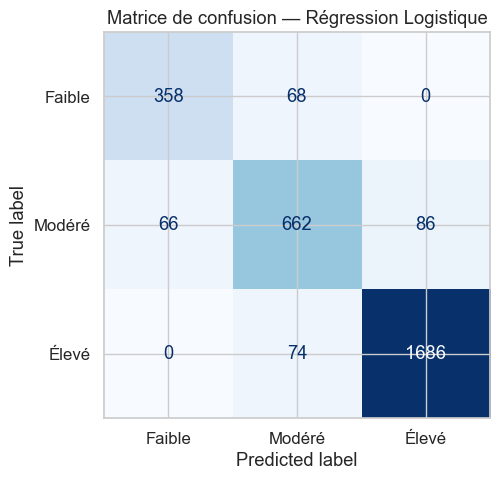

In [5]:
# Matrice de confusion - Régression Logistique
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matrice de confusion — Régression Logistique')
plt.tight_layout()
plt.show()

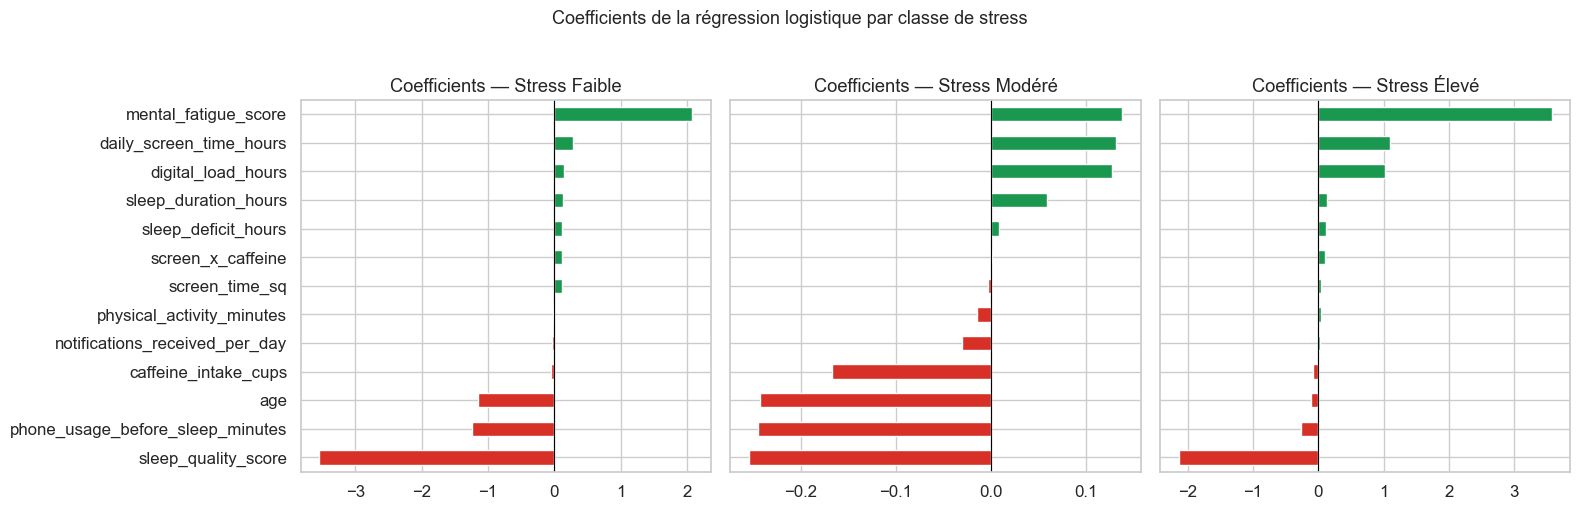

In [6]:
# Coefficients de la régression logistique (importance des features par classe)
coef_df = pd.DataFrame(lr.coef_, columns=FEATURES, index=classes)

fig, axes = plt.subplots(1, len(classes), figsize=(16, 5), sharey=True)
for ax, cls in zip(axes, classes):
    coefs = coef_df.loc[cls].sort_values()
    colors = ['#d73027' if v < 0 else '#1a9850' for v in coefs.values]
    coefs.plot(kind='barh', ax=ax, color=colors)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'Coefficients — Stress {cls}')
plt.suptitle('Coefficients de la régression logistique par classe de stress', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. SVC — Support Vector Classifier

Le SVC cherche l'**hyperplan** qui sépare les classes avec la marge maximale. Avec le noyau RBF, il gère des frontières de décision non linéaires.

In [7]:
svc = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svc.fit(X_train_s, y_train)
y_pred_svc = svc.predict(X_test_s)

print('=== SVC (RBF) ===')
print(classification_report(y_test, y_pred_svc, target_names=classes))

=== SVC (RBF) ===
              precision    recall  f1-score   support

      Faible       0.83      0.82      0.82       426
      Modéré       0.81      0.80      0.80       814
       Élevé       0.95      0.96      0.95      1760

    accuracy                           0.89      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.89      0.89      0.89      3000



## 5. Random Forest Classifier

=== Random Forest Classifier ===
              precision    recall  f1-score   support

      Faible       0.86      0.82      0.84       426
      Modéré       0.81      0.83      0.82       814
       Élevé       0.96      0.95      0.95      1760

    accuracy                           0.90      3000
   macro avg       0.87      0.87      0.87      3000
weighted avg       0.90      0.90      0.90      3000



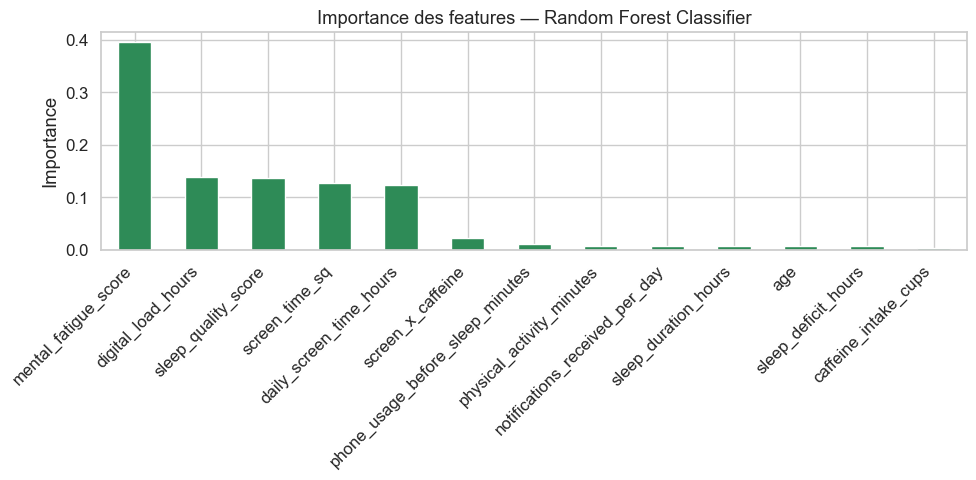

In [8]:
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=5,
                                  random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

print('=== Random Forest Classifier ===')
print(classification_report(y_test, y_pred_rf, target_names=classes))

# Importance des features
imp_rf = pd.Series(rf_clf.feature_importances_, index=FEATURES).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
imp_rf.plot(kind='bar', ax=ax, color='seagreen', edgecolor='white')
ax.set_title('Importance des features — Random Forest Classifier')
ax.set_ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Arbre de décision (visualisation)

L'arbre de décision est le modèle le plus **interprétable** : on peut visualiser exactement les règles de décision appliquées.

Accuracy Arbre de décision : 0.8837


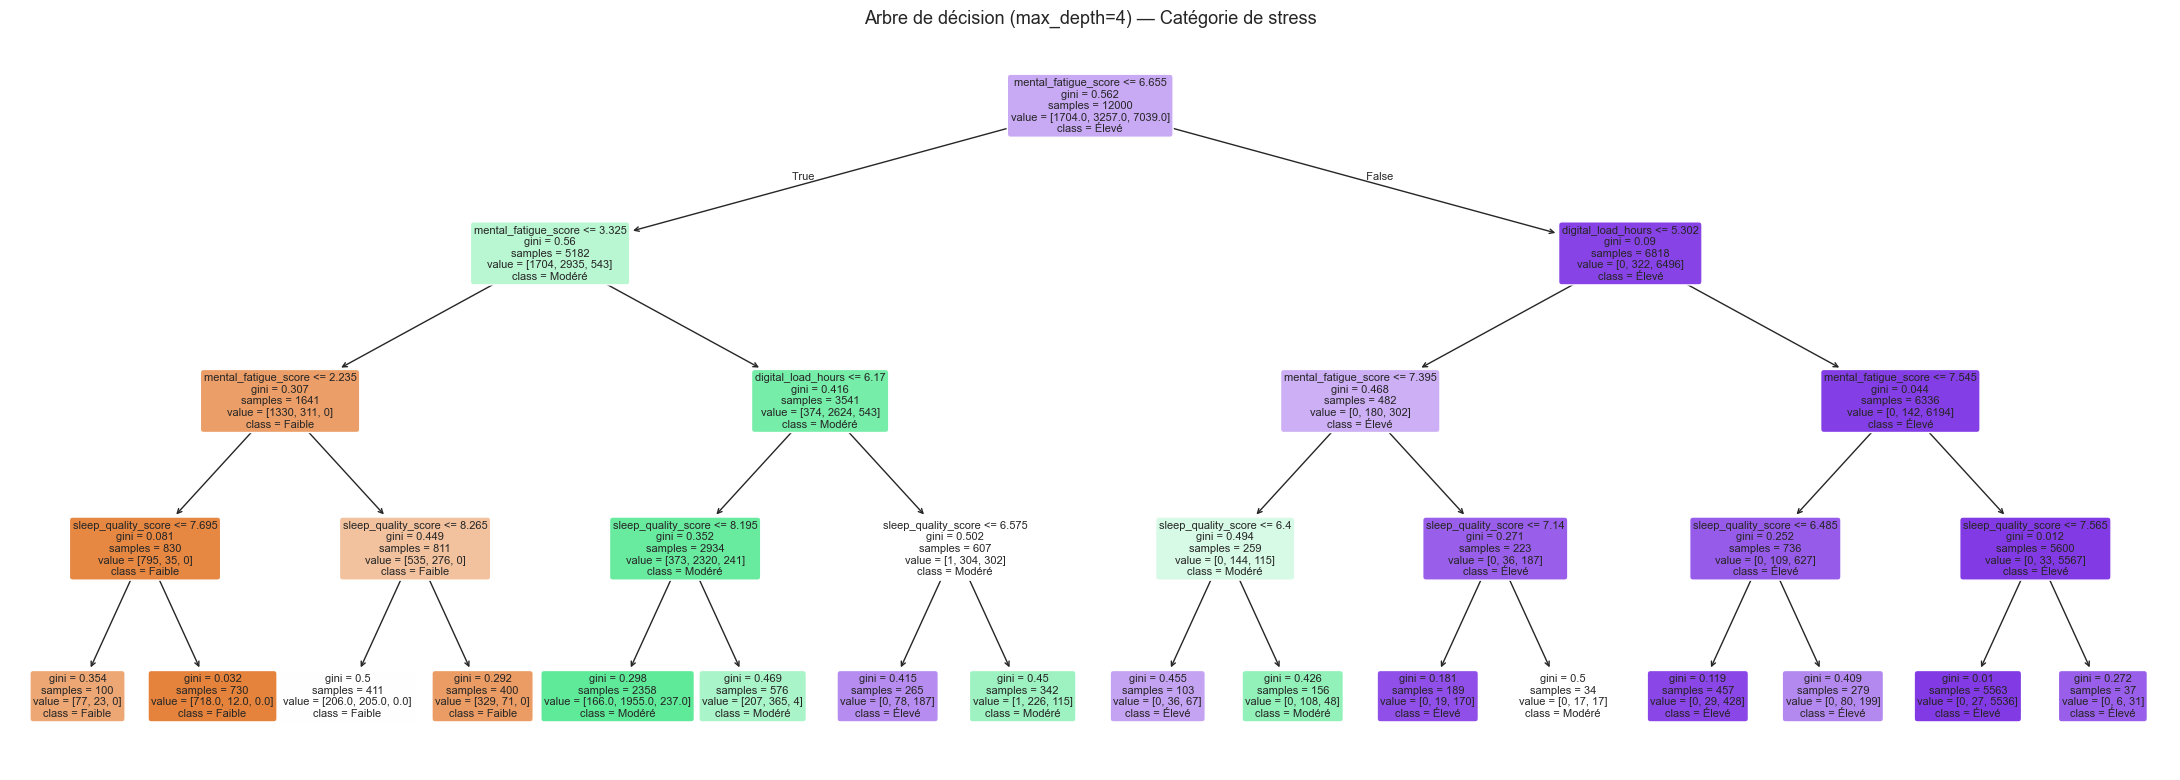

In [9]:
dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print(f'Accuracy Arbre de décision : {(y_pred_dt == y_test).mean():.4f}')

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt, feature_names=FEATURES, class_names=classes,
    filled=True, rounded=True, fontsize=8, ax=ax
)
ax.set_title('Arbre de décision (max_depth=4) — Catégorie de stress', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Courbes ROC multi-classes

La courbe ROC mesure le compromis entre **taux de vrais positifs** (sensibilité) et **taux de faux positifs**. L'AUC (aire sous la courbe) doit être le plus proche de 1.

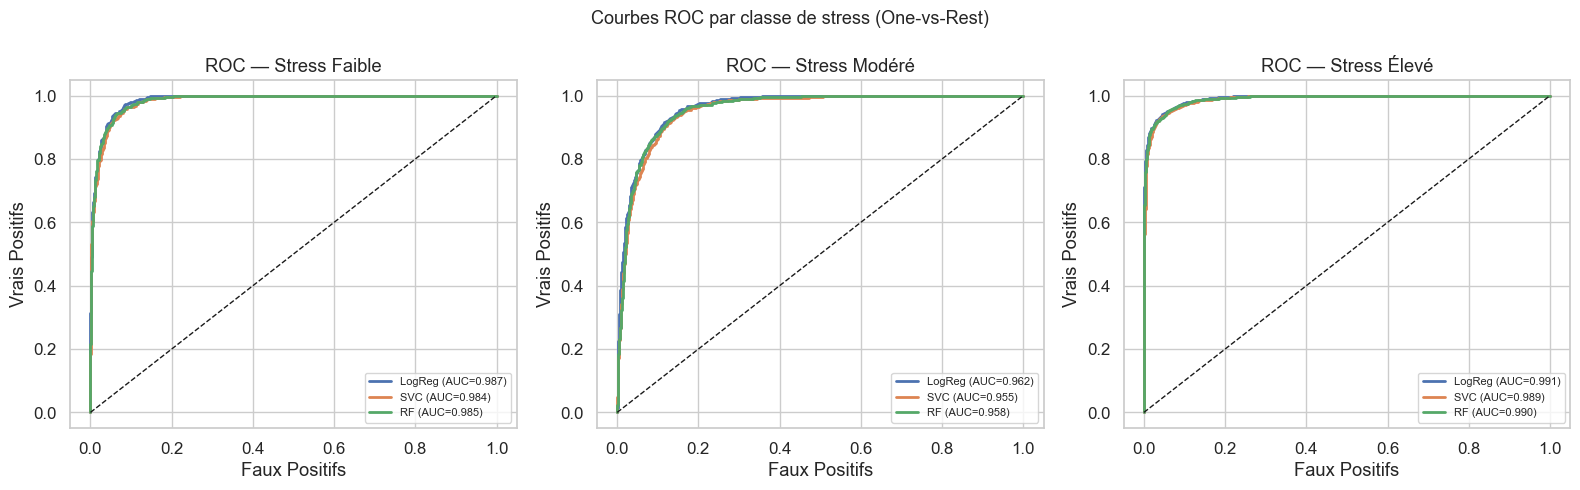

In [10]:
# Binarisation pour ROC multi-classes (One-vs-Rest)
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, cls_idx, cls_name in zip(axes, [0, 1, 2], classes):
    for name, model, X_t, needs_scale in [
        ('LogReg', lr,     X_test_s, False),
        ('SVC',    svc,    X_test_s, False),
        ('RF',     rf_clf, X_test,   False),
    ]:
        proba = model.predict_proba(X_t)[:, cls_idx]
        fpr, tpr, _ = roc_curve(y_test_bin[:, cls_idx], proba)
        auc = roc_auc_score(y_test_bin[:, cls_idx], proba)
        ax.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc:.3f})')
    ax.plot([0,1],[0,1], 'k--', lw=1)
    ax.set_xlabel('Faux Positifs')
    ax.set_ylabel('Vrais Positifs')
    ax.set_title(f'ROC — Stress {cls_name}')
    ax.legend(fontsize=8)

plt.suptitle('Courbes ROC par classe de stress (One-vs-Rest)', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Comparaison finale des modèles

=== Comparaison des modèles de classification ===
                     Accuracy  F1 macro  F1 weighted
Modèle                                              
Random Forest          0.9020    0.8719       0.9021
Logistic Regression    0.9020    0.8718       0.9017
SVC (RBF)              0.8930    0.8586       0.8927
Decision Tree          0.8837    0.8438       0.8844


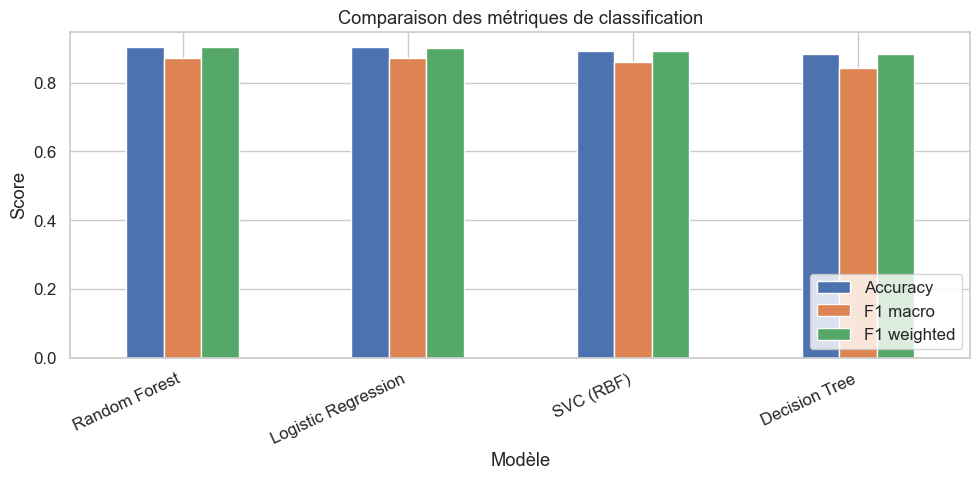

In [11]:
from sklearn.metrics import accuracy_score, f1_score

models_eval = [
    ('Logistic Regression', y_pred_lr),
    ('SVC (RBF)',            y_pred_svc),
    ('Random Forest',        y_pred_rf),
    ('Decision Tree',        y_pred_dt),
]

compar = []
for name, preds in models_eval:
    compar.append({
        'Modèle'      : name,
        'Accuracy'    : accuracy_score(y_test, preds),
        'F1 macro'    : f1_score(y_test, preds, average='macro'),
        'F1 weighted' : f1_score(y_test, preds, average='weighted'),
    })

compar_df = pd.DataFrame(compar).set_index('Modèle').round(4)
compar_df = compar_df.sort_values('F1 weighted', ascending=False)
print('=== Comparaison des modèles de classification ===')
print(compar_df.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
compar_df.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('Comparaison des métriques de classification')
ax.set_ylabel('Score')
ax.legend(loc='lower right')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

In [12]:
# Validation croisée stratifiée 5-fold pour le meilleur modèle
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Validation croisée stratifiée 5-fold :')
for name, model, Xd in [
    ('Logistic Regression', lr,     X_train_s),
    ('Random Forest',       rf_clf, X_train),
]:
    cv = cross_val_score(model, Xd, y_train, cv=skf, scoring='f1_weighted')
    print(f'  {name:<25}  F1-weighted : {cv.mean():.4f} ± {cv.std():.4f}')

Validation croisée stratifiée 5-fold :
  Logistic Regression        F1-weighted : 0.9019 ± 0.0077
  Random Forest              F1-weighted : 0.8989 ± 0.0077
